In [1]:
%load_ext autoreload
%autoreload 2 
import sys
sys.path.append('/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/scripts')
import funcs as fun
import xarray as xr
import rioxarray



/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/scripts/funcs.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


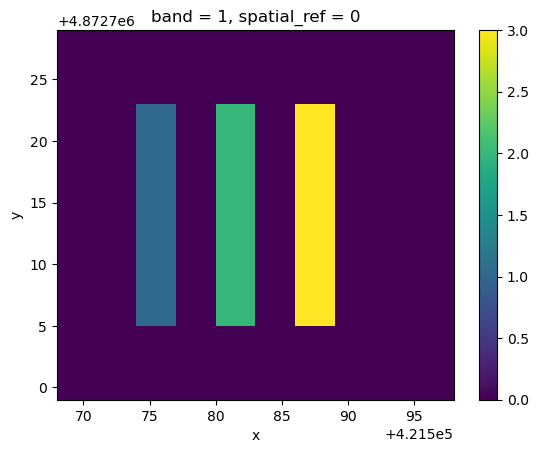

In [4]:
fun.fsm('downloaded.dem', uniform_melt = 1, load_dh=True).plot()

In [15]:

dem = rioxarray.open_rasterio('downloaded.dem')

input_water = xr.zeros_like(dem) +1
input_water.rio.to_raster('input_water.tif')

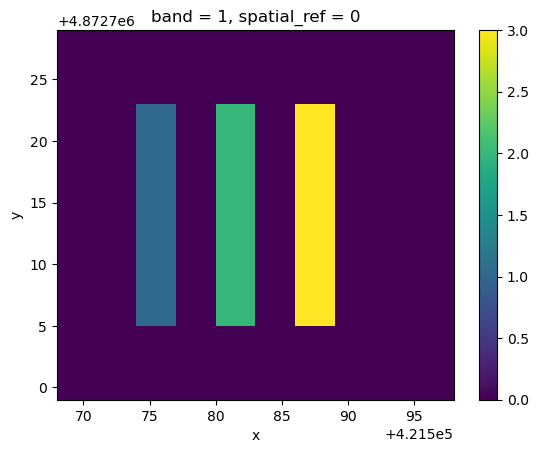

In [3]:
fun.fsm('downloaded.dem', melt_filename = 'input_water.tif').plot()

In [9]:
fun.fsm_xarray()

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


ValueError: cannot reindex or align along dimension 'x' because the (pandas) index has duplicate values

In [23]:
dem = rioxarray.open_rasterio("/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/rema_subsets/dem_small_2.tif", chunks={})
dem

<xarray.DataArray (band: 1, y: 3072, x: 1024)> Size: 13MB
dask.array<open_rasterio-b9d313f023e52eded86b03a8278e9682<this-array>, shape=(1, 3072, 1024), dtype=float32, chunksize=(1, 3072, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 8kB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * y            (y) float64 25kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    AREA_OR_POINT:       Area
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

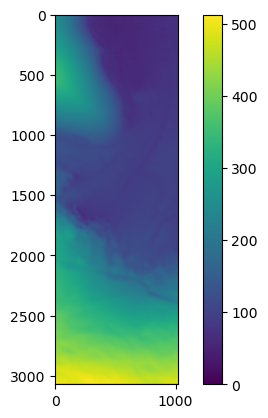

In [47]:
import matplotlib.pyplot as plt
plt.imshow(dem.values.squeeze())
plt.colorbar()

In [5]:
import pdemtools as pdt

In [6]:
%%time
width = 25000
height = 50000
bounds = (817500.0- width, 1.9325e6-height, 817500.0+width, 1.9325e6+height)
dem_2 = pdt.load.mosaic(
    dataset='rema',  # must be `arcticdem` or `rema`
    resolution=32,        # must be 2, 10, or 32
    bounds=bounds,
    chunks = {})

CPU times: user 312 ms, sys: 79.4 ms, total: 391 ms
Wall time: 10.2 s


In [7]:
dem_2

<xarray.DataArray (y: 3126, x: 1564)> Size: 20MB
array([[337.31326 , 337.4508  , 337.61526 , ...,  78.56963 ,  78.44607 ,
         78.31859 ],
       [337.12616 , 337.2825  , 337.3952  , ...,  78.55038 ,  78.42869 ,
         78.3078  ],
       [336.91284 , 337.06677 , 337.1841  , ...,  78.554115,  78.41735 ,
         78.30152 ],
       ...,
       [678.1973  , 677.689   , 677.2389  , ..., 667.6586  , 667.5892  ,
        667.49316 ],
       [678.3062  , 677.7977  , 677.3557  , ..., 667.9818  , 667.98126 ,
        667.92883 ],
       [678.4394  , 677.9322  , 677.4972  , ..., 668.2846  , 668.3096  ,
        668.32635 ]], shape=(3126, 1564), dtype=float32)
Coordinates:
  * x            (x) float64 13kB 7.925e+05 7.925e+05 ... 8.425e+05 8.425e+05
  * y            (y) float64 25kB 1.983e+06 1.982e+06 ... 1.883e+06 1.883e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     -9999.0

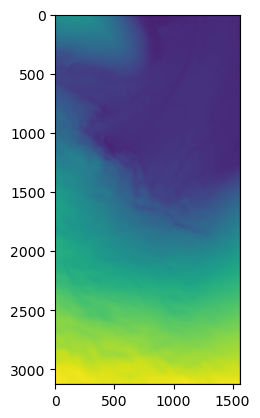

In [56]:
plt.imshow(dem_2.squeeze().values)

In [9]:
dem, dem_loaded =  fun.load_REMA_subset(save_tiff = True)

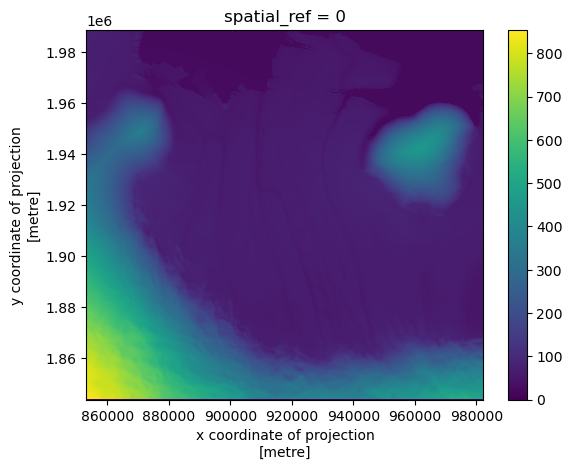

In [11]:
dem.plot()

In [42]:
dem_2[0:1,:] = 0.0 
dem_2[-1:,:] = 0.0
dem_2[:,0:1] = 0.0
dem_2[:,-1:] = 0.0
dem_2.rio.to_raster('dem_2.tif')

In [43]:
wtd = fun.fsm('dem_2.tif', uniform_melt = 1)

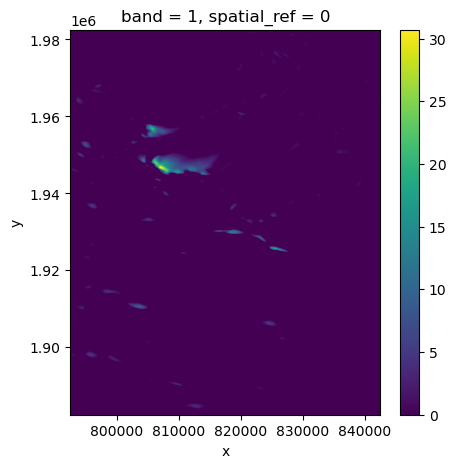

In [46]:
wtd.plot(size = 5, aspect = 1)

In [12]:
out = fun.fsm_xarray()
out

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


ValueError: cannot reindex or align along dimension 'x' because the (pandas) index has duplicate values

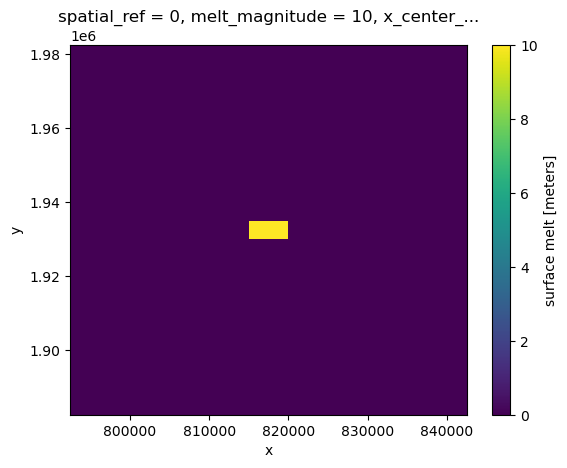

In [63]:
out.melt.plot()

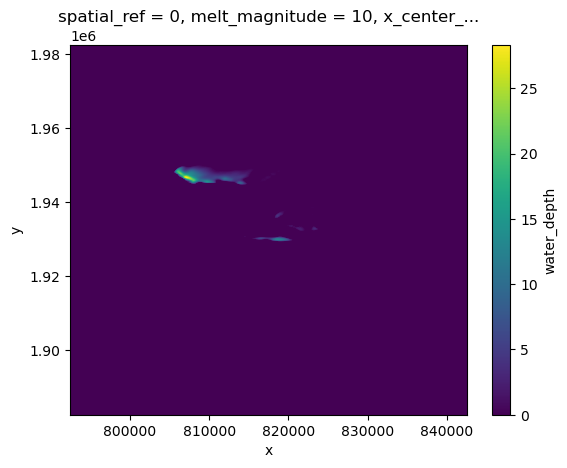

In [64]:
out.water_depth.plot()

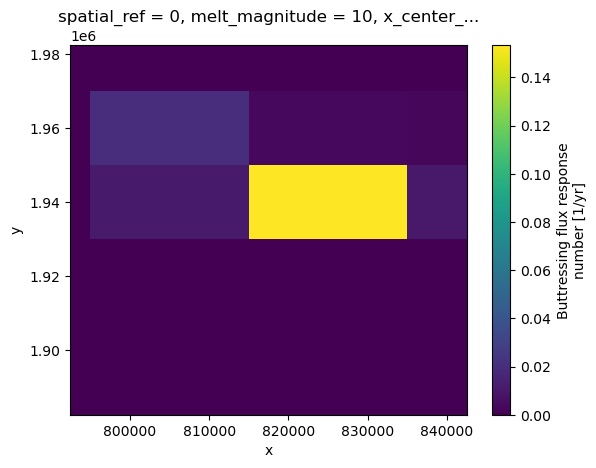

In [65]:
out.bfrn.plot()

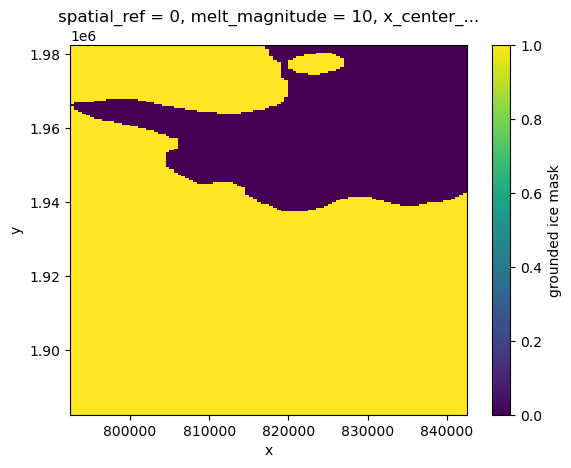

In [66]:
out.grounded_mask.plot()

In [69]:
out.total_GL_flux_response.compute()

<xarray.DataArray 'total_GL_flux_response' ()> Size: 8B
array(3.29972987e+10)
Coordinates:
    spatial_ref       int64 8B 0
    melt_magnitude    int64 8B 10
    x_center_of_melt  float64 8B 8.175e+05
    y_center_of_melt  float64 8B 1.932e+06
    melt_width        int64 8B 5000
    dem_filename      <U9 36B 'dem_2.tif'
    band              int64 8B 1
Attributes:
    units:        kg/yr
    description:  The total instantaneous change in grounding line flux due t...